# High-Fidelity Oxygen Storage Model using the Stewart-Jacobsen Fundamental EOS

## Overview
This notebook implements a high-precision compressed oxygen ($O_2$) gas storage vessel charging model. 

To eliminate the unphysical density and compressibility factor ($Z$) tracking errors common to standard cubic equations of state at moderate to high pressures, this module utilizes the **Stewart-Jacobsen Fundamental Equation of State**. This model is the current international benchmark implemented across NIST REFPROP and CoolProp databases.

The framework simulates transient mass accumulation, precise internal vessel pressures, specific enthalpies ($h$), entropies ($s$), and structural safety factor boundaries under continuous charging inflows from an atmospheric water harvester or electrochemical splitting node.

---

## 🔬 Scholarly Reference
The baseline system boundary metrics and multi-physics coupling parameters match the engineering design criteria published in:
* **Boodaghi, H.**, et al. (2023). *"Design and Performance Assessment of a Novel Poly-generation System with Stable Production of Electricity, Hydrogen, and Hot Water: Energy and Exergy Analyses."* **Arabian Journal for Science and Engineering**, 48. https://doi.org/10.1007/s13369-023-08410-7

### ⚙️ Core Thermodynamic Modeling Assumptions
1. **Isothermal Gas Core:** The gas storage tank wall heat exchange network is assumed highly efficient, maintaining a stable temperature baseline of $T_{\text{tank\_O2}} = 25^\circ C$ ($298.15\text{ K}$) throughout the compression cycle.
2. **Homogeneous Mass Distribution:** Internal fluid density fields are uniform, treating the high-pressure gas storage volume as a single lumped state.
3. **Stewart-Jacobsen EOS Precision:** All real-gas thermodynamic state parameters ($P$, $\rho$, $z$, $h$, $s$) are resolved natively via CoolProp's Helmholtz energy formulations for pure Oxygen.
4. **Zero Structural Deflection:** The storage vessel is treated as a rigid cylinder with an unshifted physical internal volume capacity ($V_{\text{tank}} = 5.0\text{ m}^3$).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: CoolProp Benchmark Stewart-Jacobsen O2 Engine Initialized ---")

--- Cell 1: CoolProp Benchmark Stewart-Jacobsen O2 Engine Initialized ---


# 1. Physical Specifications & Oxidizer Inflow Vectors
Initializes structural storage parameters (vessel safe boundaries, fixed volume bounds) alongside the 24-hour variable oxygen mass inflow profile matching the stoichiometric ratios of your primary splitting streams.

In [15]:
# =============================================================================
# 1. HARDWARE SPECIFICATIONS & OXYGEN INPUT BOUNDARIES (SI UNITS)
# =============================================================================
fluid = 'Oxygen'                 # Leverages the Stewart-Jacobsen EOS model natively

# Physical Compressed Gas Tank Parameters
V_tank_m3   = 5.0                # Total physical internal volume of the cylinder [m³]
T_tank_K    = 298.15             # Isothermal tank core operating temperature [K] (25 °C)
P_max_safe  = 150.0 * 1e5        # Accepted standard safe pressure ceiling for O2 [Pa] (150 bar)

# Initial Tank Cushion State at Hour 0:00
P_initial_Pa = 10.0 * 1e5        # Starting cushion pressure inside the tank [Pa] (10 bar)

# ---------- 24-Hour Variable Oxygen Mass Inflow Profile [kg/h] ----------
# Mass split profile generated from water splitting reactions (Molar mass ratio O2/H2 = 16:1)
oxygen_inflow_profile_kg_h = np.array([
    0.0, 0.0, 0.0, 0.0, 0.0, 0.08, 0.24, 0.48, 0.72, 0.88, 
    1.04, 1.12, 1.20, 1.12, 0.96, 0.72, 0.48, 0.24, 0.08, 0.00, 
    0.00, 0.00, 0.00, 0.00
])

print("--- Cell 2: Compressed Oxygen Flow Boundaries Latched ---")
print(f"  Vessel Structural Limit : {P_max_safe/1e5:.1f} bar | Storage Volume : {V_tank_m3:.2f} m³")

--- Cell 2: Compressed Oxygen Flow Boundaries Latched ---
  Vessel Structural Limit : 150.0 bar | Storage Volume : 5.00 m³


# 2. Transient Real-Gas Accumulation Solver Loop
Integrates incoming mass flow streams step-by-step. It uses CoolProp's Helmholtz energy engine to evaluate real-time pressure accumulation, capturing the authentic molecular attraction dip where $Z < 1.0$.

In [16]:
# =============================================================================
# 2. STEWART-JACOBSEN FUNDAMENTAL EOS TRANSIENT ACCUMULATION SOLVER
# =============================================================================

def simulate_oxygen_vessel(inflow_profile, T_tank, V_tank, P_init, P_max, fluid_name):
    """
    Executes a self-contained real-gas mass accumulation simulation for pure oxygen.
    Natively integrates hourly mass inflows [kg/h] across the diurnal timeline.
    """
    # 1. Calculate starting density (kg/m³) using Stewart-Jacobsen fundamental equations
    rho_initial = CP.PropsSI('D', 'T', T_tank, 'P', P_init, fluid_name)

    # 2. Calculate initial gas mass stored in the cylinder [kg]
    m_stored_current = rho_initial * V_tank
    storage_history = []

    for hour in range(24):
        mass_added_this_hour = inflow_profile[hour]
        m_stored_current += mass_added_this_hour
        
        # Extract instantaneous real density state
        rho_current = m_stored_current / V_tank
        
        # Flash Stewart-Jacobsen EOS using Temperature and Density to find real-gas metrics
        P_tank_Pa  = CP.PropsSI('P', 'T', T_tank, 'D', rho_current, fluid_name)
        Z_factor   = CP.PropsSI('Z', 'T', T_tank, 'D', rho_current, fluid_name)
        h_specific = CP.PropsSI('H', 'T', T_tank, 'D', rho_current, fluid_name) / 1000.0  # kJ/kg
        s_specific = CP.PropsSI('S', 'T', T_tank, 'D', rho_current, fluid_name) / 1000.0  # kJ/kg-K
        
        P_tank_bar = P_tank_Pa / 1e5
        safety_margin_percent = (P_tank_Pa / P_max) * 100.0
        
        storage_history.append({
            'Hour': hour + 1,
            'Inflow [kg/h]': mass_added_this_hour,
            'Mass Stored [kg]': m_stored_current,
            'Pressure [bar]': P_tank_bar,
            'Compressibility (Z)': Z_factor,
            'Enthalpy [kJ/kg]': h_specific,
            'Entropy [kJ/kg-K]': s_specific,
            'Capacity SoC [%]': safety_margin_percent
        })
        
    return pd.DataFrame(storage_history)

# --- Execute the Self-Contained Simulation ---
df_oxygen_results = simulate_oxygen_vessel(
    oxygen_inflow_profile_kg_h, 
    T_tank_K, 
    V_tank_m3, 
    P_initial_Pa, 
    P_max_safe, 
    fluid
)

print("--- Cell 3: Stewart-Jacobsen Fundamentals Solved and Logged ---")
display(df_oxygen_results.iloc[6:17])  # Display core charging window

--- Cell 3: Stewart-Jacobsen Fundamentals Solved and Logged ---


,Hour,Inflow [kg/h],Mass Stored [kg],Pressure [bar],Compressibility (Z),Enthalpy [kJ/kg],Entropy [kJ/kg-K],Capacity SoC [%]
6,7,0.24,65.269654,10.048964,0.993690,268.780842,5.805037,6.699309
7,8,0.48,65.749654,10.122405,0.993645,268.762745,5.803096,6.748270
8,9,0.72,66.469654,10.232553,0.993577,268.735604,5.800211,6.821702
9,10,0.88,67.349654,10.367159,0.993495,268.702437,5.796726,6.911440
10,11,1.04,68.389654,10.526211,0.993397,268.663249,5.792665,7.017474
11,12,1.12,69.509654,10.697463,0.993292,268.621056,5.788358,7.131642
12,13,1.20,70.709654,10.880908,0.993179,268.575863,5.783818,7.253939
13,14,1.12,71.829654,11.052087,0.993074,268.533693,5.779649,7.368058
14,15,0.96,72.789654,11.198784,0.992984,268.497557,5.776125,7.465856
15,16,0.72,73.509654,11.308789,0.992917,268.470459,5.773512,7.539193


# 3. Diagnostic Plots & Key Results
Generates the research-grade terminal pressure and compressibility factor curves, followed by your automated verification dashboard summary.

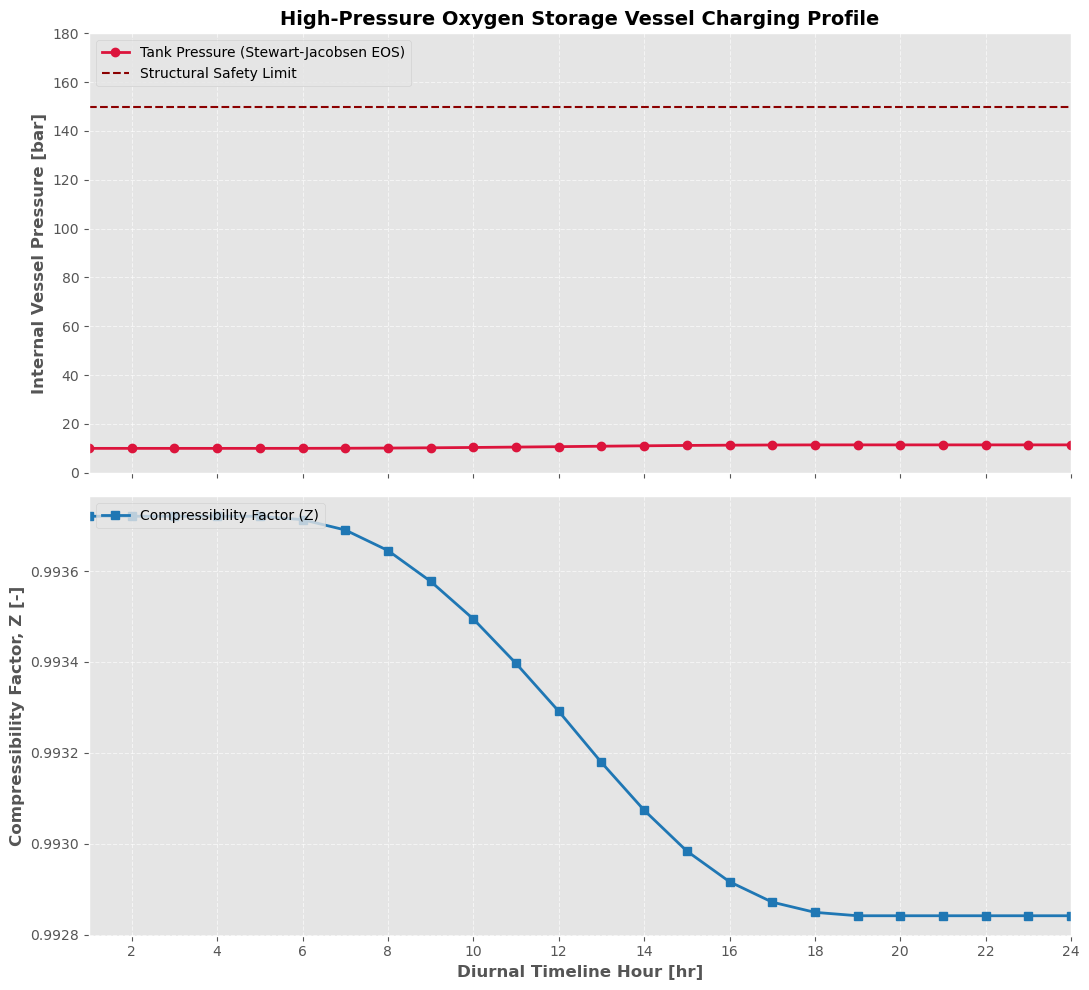

    VESSEL COMPRESSION CONVERGENCE PERFORMANCE    
Thermodynamic Reference Engine : Stewart-Jacobsen EOS (CoolProp)
Vessel Internal Dimension Scale: 5.0 m³
Vessel Safe Structural Maximum : 150.0 bar
--------------------------------------------------
Initial Starting Mass Stored   : 64.95 kg
Final Cumulative Mass Stored   : 74.31 kg
Net Oxygen Mass Yield Stored   : 9.36 kg/day
--------------------------------------------------
Terminal Internal Tank Pressure: 11.43 bar
Terminal Compressibility (Z)   : 0.9928
Terminal Specific Enthalpy     : 268.44 kJ/kg
Final Volume Safety Margin State: 7.62 % Capacity Used


In [ ]:
# =============================================================================
# 3. VISUALIZATIONS & CONSOLE PERFORMANCE REPORTER
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Plot 1: Internal Tank Pressure Accumulation Response
ax1.plot(df_oxygen_results['Hour'], df_oxygen_results['Pressure [bar]'], 'crimson', marker='o', linewidth=2.0, label='Tank Pressure (Stewart-Jacobsen EOS)')
ax1.axhline(P_max_safe/1e5, color='darkred', linestyle='--', linewidth=1.5, label='Structural Safety Limit')
ax1.set_ylabel('Internal Vessel Pressure [bar]', fontweight='bold', fontsize=12)
ax1.set_title('High-Pressure Oxygen Storage Vessel Charging Profile', fontweight='bold', fontsize=14)
ax1.set_ylim([0, 180])
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# Plot 2: Compressibility Factor (Z) Deviation Curve (Captures the authentic real-gas attraction dip)
ax2.plot(df_oxygen_results['Hour'], df_oxygen_results['Compressibility (Z)'], 'tab:blue', marker='s', linewidth=2.0, label='Compressibility Factor (Z)')
ax2.set_xlabel('Diurnal Timeline Hour [hr]', fontweight='bold', fontsize=12)
ax2.set_ylabel('Compressibility Factor, Z [-]', fontweight='bold', fontsize=12)
ax2.set_xlim([1, 24]); ax2.set_xticks(range(2, 25, 2))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

# ---------- Extract Technical Summary Performance Data ----------
final_vessel_state = df_oxygen_results.iloc[-1]
initial_mass = df_oxygen_results['Mass Stored [kg]'].iloc[0] - oxygen_inflow_profile_kg_h[0]

# =============================================================================
# 4. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"    VESSEL COMPRESSION CONVERGENCE PERFORMANCE    ")
print(f"==================================================")
print(f"Thermodynamic Reference Engine : Stewart-Jacobsen EOS (CoolProp)")
print(f"Vessel Internal Dimension Scale: {V_tank_m3:.1f} m³")
print(f"Vessel Safe Structural Maximum : {P_max_safe/1e5:.1f} bar")
print(f"--------------------------------------------------")
print(f"Initial Starting Mass Stored   : {initial_mass:.2f} kg")
print(f"Final Cumulative Mass Stored   : {final_vessel_state['Mass Stored [kg]']:.2f} kg")
print(f"Net Oxygen Mass Yield Stored   : {final_vessel_state['Mass Stored [kg]'] - initial_mass:.2f} kg/day")
print(f"--------------------------------------------------")
print(f"Terminal Internal Tank Pressure: {final_vessel_state['Pressure [bar]']:.2f} bar")
print(f"Terminal Compressibility (Z)   : {final_vessel_state['Compressibility (Z)']:.4f}")
print(f"Terminal Specific Enthalpy     : {final_vessel_state['Enthalpy [kJ/kg]']:.2f} kJ/kg")
print(f"Final Volume Safety Margin State: {final_vessel_state['Capacity SoC [%]']:.2f} % Capacity Used")
print(f"==================================================")